# 1. Exploratory Data Analysis

### Freight Rate Predication

**The Purpose of this notebook** is Understand what drives freight rates.

The following four questions are answered:

1. What does the data contain, and is it the same across the three files?
2. What actually moves the price of a load?
3. How does price behave over time?
4. How different is the data we must predict from the data we learn from?

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.color": "#D9E2E4",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

ACCENT = "#064A56"
GREY = "#9DAFB3"

DATA = Path("../data")
FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

def save(name):
    """Save the current figure into reports/figures/ for reuse in the report."""
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", bbox_inches="tight", dpi=150)

print("Setup complete.")

Setup complete.


## Load Dataset

In [3]:
train = pd.read_csv(DATA / "train-test.csv", parse_dates=["date"])
val = pd.read_csv(DATA / "validation.csv", parse_dates=["date"])
dec = pd.read_csv(DATA / "december-chart-inputs.csv", parse_dates=["date"])

print(f"train_test.csv            : {train.shape[0]:>6,} rows x {train.shape[1]} columns")
print(f"validation.csv            : {val.shape[0]:>6,} rows x {val.shape[1]} columns")
print(f"december_chart_inputs.csv : {dec.shape[0]:>6,} rows x {dec.shape[1]} columns")

train.head()

train_test.csv            : 48,000 rows x 14 columns
validation.csv            : 12,000 rows x 13 columns
december_chart_inputs.csv :     31 rows x 7 columns


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## Schema Overview

For every column: its type, how much is missing, and how many distinct value it holds

In [4]:
schema = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "n_missing": train.isna().sum(),
    "pct_missing": (train.isna().mean() * 100).round(2),
    "n_unique": train.nunique(),
})
schema

,dtype,n_missing,pct_missing,n_unique
load_id,object,0,0.00,48000
pickup,object,0,0.00,64
delivery,object,0,0.00,64
pickup_lat,float64,0,0.00,64
pickup_lon,float64,0,0.00,63
delivery_lat,float64,0,0.00,64
delivery_lon,float64,0,0.00,63
distance,float64,0,0.00,21204
equipment,object,0,0.00,3
weight,float64,300,0.62,23678


## Feature availability across the three files

This is to check if the features present in the training file are present in the prediction file too, excepts for the target column

In [5]:
all_cols = sorted(set(train.columns) | set(val.columns) | set(dec.columns))
availability = pd.DataFrame({
    "train_test": [c in train.columns for c in all_cols],
    "validation": [c in val.columns for c in all_cols],
    "december_chart": [c in dec.columns for c in all_cols],
}, index=all_cols).replace({True: "yes", False: "—"})
availability

,train_test,validation,december_chart
date,yes,yes,yes
delivery,yes,yes,yes
delivery_lat,yes,yes,—
delivery_lon,yes,yes,—
distance,yes,yes,yes
equipment,yes,yes,yes
load_id,yes,yes,—
market_index,yes,yes,—
pickup,yes,yes,yes
pickup_lat,yes,yes,—


## Studying the Target Column

In [6]:
rate = train["posted_rate"]
print(rate.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2))
print(f"\nSkewness        : {rate.skew():.3f}")
print(f"Skewness of log : {np.log(rate).skew():.3f}")

count    48000.00
mean      2373.98
std       1486.49
min         57.22
1%         327.17
5%         599.74
25%       1251.55
50%       2030.76
75%       3330.75
95%       4953.77
99%       5972.83
max      25533.00
Name: posted_rate, dtype: float64

Skewness        : 1.902
Skewness of log : -0.491


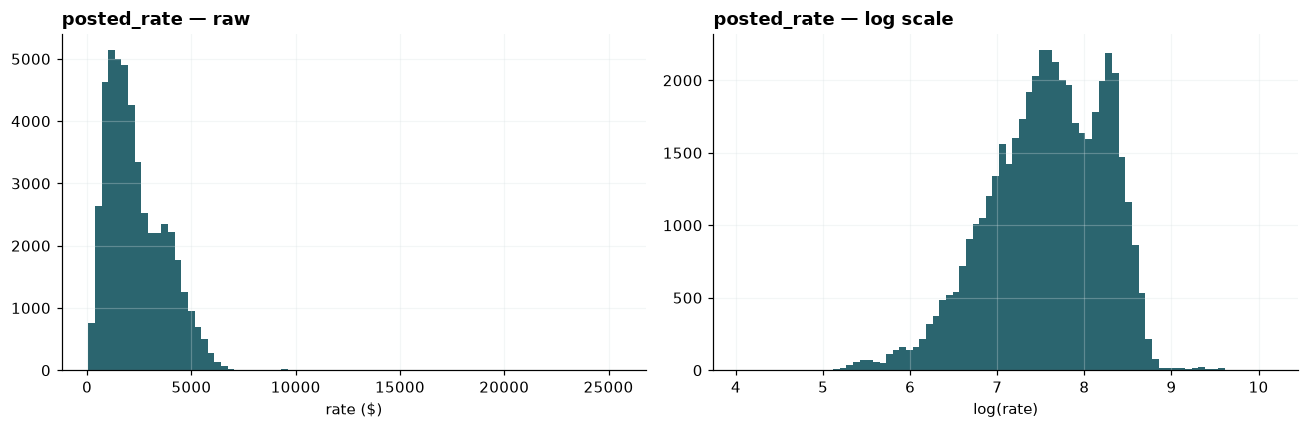

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rate, bins=80, color=ACCENT, alpha=0.85)
axes[0].set_title("posted_rate — raw", loc="left", fontweight="bold")
axes[0].set_xlabel("rate ($)")

axes[1].hist(np.log(rate), bins=80, color=ACCENT, alpha=0.85)
axes[1].set_title("posted_rate — log scale", loc="left", fontweight="bold")
axes[1].set_xlabel("log(rate)")
save("01_target_distribution")
plt.show()

## Rate per mile: The right unit for analysis

This is done by dividing by distance to give **rate per mile (RPM)**, which puts every load on the same scale.
This is the standard measure in freight and it is what i use for the rest of the analysis.

In [8]:
train["rate_per_mile"] = train["posted_rate"] / train["distance"]
print(train["rate_per_mile"].describe(percentiles=[.001, .01, .05, .5, .95, .99, .999]).round(3))

count    48000.000
mean         2.215
std          0.584
min          0.334
0.1%         0.437
1%           1.674
5%           1.808
50%          2.145
95%          2.736
99%          3.177
99.9%       10.069
max         14.125
Name: rate_per_mile, dtype: float64


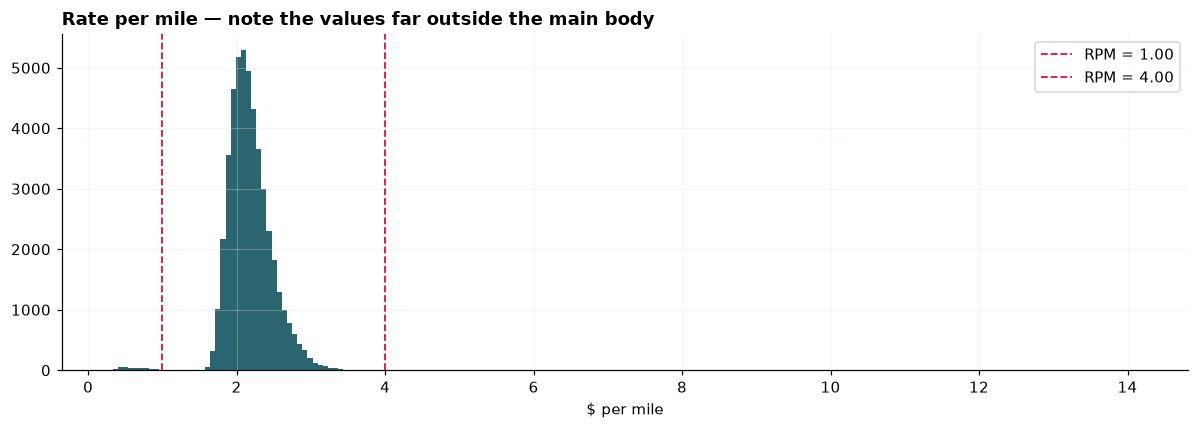

In [9]:
plt.figure(figsize=(11, 4))
plt.hist(train["rate_per_mile"], bins=200, color=ACCENT, alpha=0.85)
plt.axvline(1.0, color="crimson", ls="--", lw=1.2, label="RPM = 1.00")
plt.axvline(4.0, color="crimson", ls="--", lw=1.2, label="RPM = 4.00")
plt.title("Rate per mile — note the values far outside the main body",
          loc="left", fontweight="bold")
plt.xlabel("$ per mile")
plt.legend()
save("01_rate_per_mile")
plt.show()

In [10]:
CLEAN = train["rate_per_mile"].between(1.0, 4.0)
clean = train[CLEAN].copy()

print(f"Working subset : {CLEAN.sum():,} of {len(train):,} rows ({CLEAN.mean()*100:.2f}%)")
print(f"Excluded here  : {(~CLEAN).sum():,} rows — analysed in notebook 02")

Working subset : 47,331 of 48,000 rows (98.61%)
Excluded here  : 669 rows — analysed in notebook 02


## Exploring the Distance Column: The Dominant Driver

In [11]:
print("Correlation with posted_rate  :", round(train[["distance", "posted_rate"]].corr().iloc[0, 1], 4))
print("Correlation with rate_per_mile:", round(clean[["distance", "rate_per_mile"]].corr().iloc[0, 1], 4))

bands = pd.cut(clean["distance"], [0, 250, 500, 1000, 1500, 2500, 4000])
clean.groupby(bands).agg(
    n=("posted_rate", "size"),
    mean_rate=("posted_rate", "mean"),
    mean_rpm=("rate_per_mile", "mean"),
).round(2)

Correlation with posted_rate  : 0.9085
Correlation with rate_per_mile: -0.6945


,n,mean_rate,mean_rpm
distance,,,
"(0, 250]",2665,479.91,2.76
"(250, 500]",7471,925.86,2.44
"(500, 1000]",14835,1641.36,2.21
"(1000, 1500]",8884,2542.49,2.09
"(1500, 2500]",10826,3868.73,1.99
"(2500, 4000]",2650,5308.77,1.89


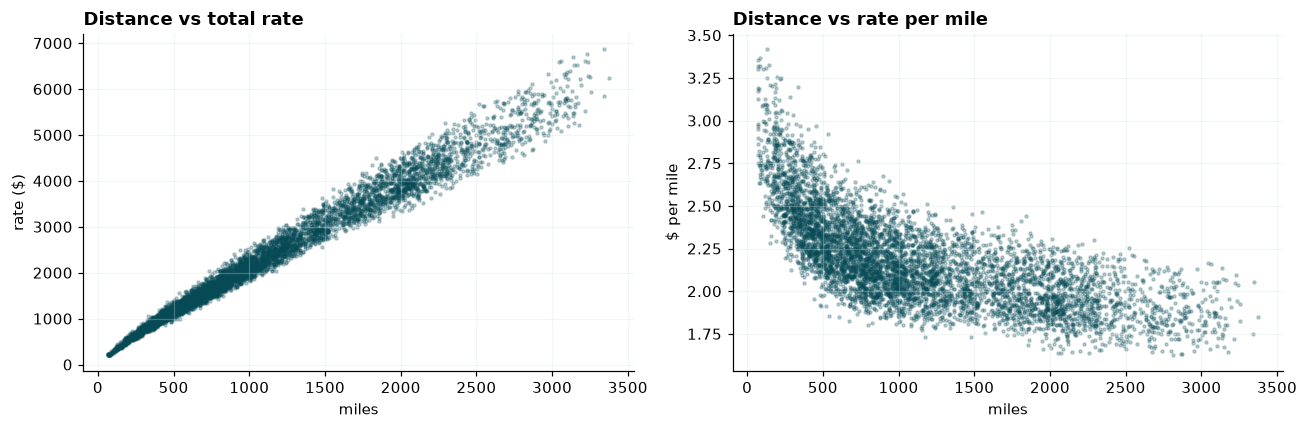

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample = clean.sample(6000, random_state=42)
axes[0].scatter(sample["distance"], sample["posted_rate"], s=4, alpha=0.25, color=ACCENT)
axes[0].set_title("Distance vs total rate", loc="left", fontweight="bold")
axes[0].set_xlabel("miles"); axes[0].set_ylabel("rate ($)")

axes[1].scatter(sample["distance"], sample["rate_per_mile"], s=4, alpha=0.25, color=ACCENT)
axes[1].set_title("Distance vs rate per mile", loc="left", fontweight="bold")
axes[1].set_xlabel("miles"); axes[1].set_ylabel("$ per mile")
save("01_distance")
plt.show()

## Equipement type

Three trailer types appear. They serve different cargo and cost different amounts to operate.

               n  share  mean_rpm  median_rpm
equipment                                    
Dry Van    26836  0.567     2.087       2.046
Flatbed     8628  0.182     2.263       2.220
Reefer     11867  0.251     2.356       2.312


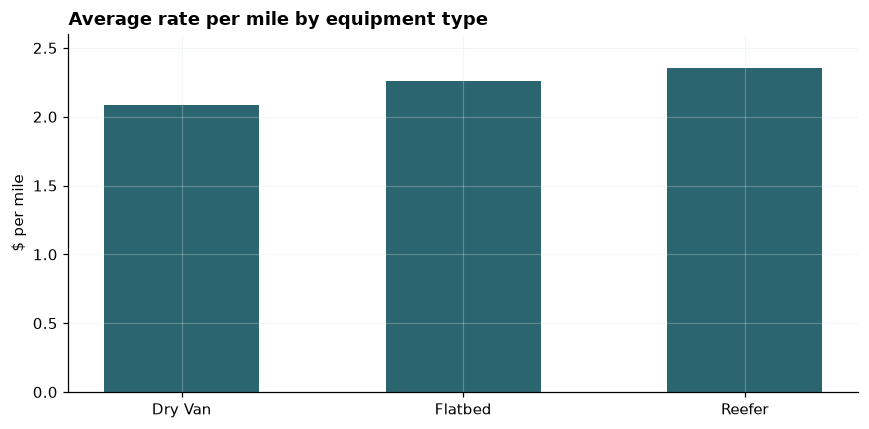

In [13]:
summary = clean.groupby("equipment").agg(
    n=("posted_rate", "size"),
    share=("posted_rate", lambda s: len(s) / len(clean)),
    mean_rpm=("rate_per_mile", "mean"),
    median_rpm=("rate_per_mile", "median"),
).round(3)
print(summary)

plt.figure(figsize=(8, 4))
order = summary.sort_values("mean_rpm").index
plt.bar(order, summary.loc[order, "mean_rpm"], color=ACCENT, alpha=0.85, width=0.55)
plt.title("Average rate per mile by equipment type", loc="left", fontweight="bold")
plt.ylabel("$ per mile"); plt.ylim(0, 2.6)
save("01_equipment")
plt.show()

## Weight

Heavier loads burn more fuel, so they should cost more.

In [14]:
w = clean.dropna(subset=["weight"])
print(w.groupby(pd.qcut(w["weight"], 5)).agg(
    n=("rate_per_mile", "size"),
    mean_rpm=("rate_per_mile", "mean"),
).round(3))

print("\nCorrelation weight vs rate_per_mile:",
      round(w[["weight", "rate_per_mile"]].corr().iloc[0, 1], 4))

                          n  mean_rpm
weight                               
(-47500.001, 24453.0]  9408     2.109
(24453.0, 29322.0]     9408     2.150
(29322.0, 33555.0]     9407     2.188
(33555.0, 38374.0]     9406     2.235
(38374.0, 47500.0]     9405     2.251

Correlation weight vs rate_per_mile: 0.1572


## Time: the seasonal pattern

Since the evaluation loads occur beyond the training period, I want to understand how rates change over time. The smoothed daily average rate per mile makes the seasonal pattern easier to see.

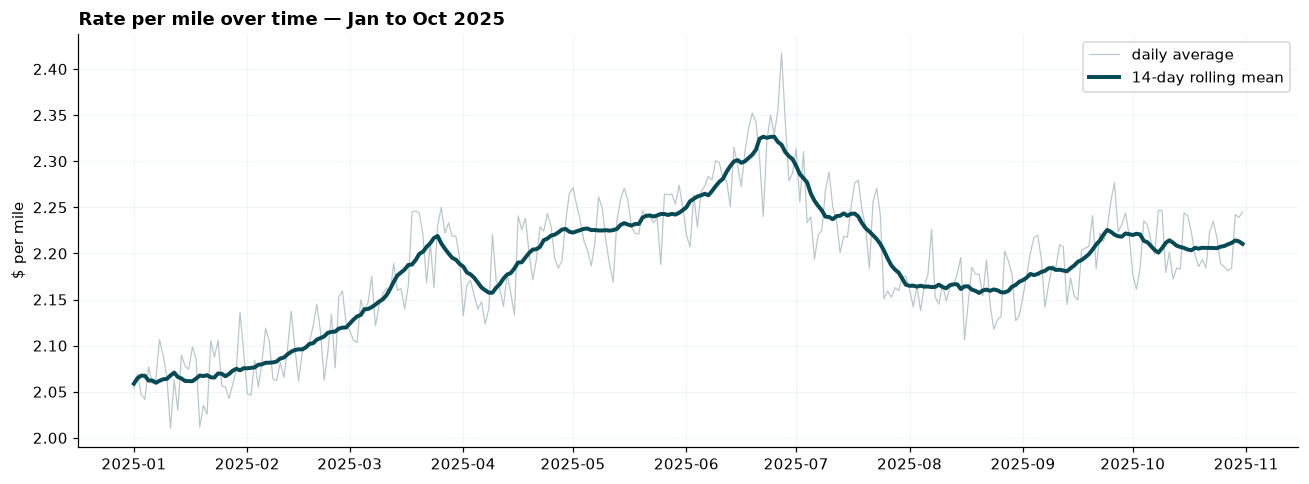

,n,mean_rpm
date,,
2025-01,4837,2.068
2025-02,4282,2.096
2025-03,4965,2.179
2025-04,4753,2.186
2025-05,4852,2.236
2025-06,4722,2.297
2025-07,4847,2.227
2025-08,4693,2.161
2025-09,4606,2.201


In [15]:
daily = clean.groupby("date")["rate_per_mile"].mean()
smooth = daily.rolling(14, center=True, min_periods=5).mean()

plt.figure(figsize=(12, 4.5))
plt.plot(daily.index, daily.values, color=GREY, lw=0.8, alpha=0.7, label="daily average")
plt.plot(smooth.index, smooth.values, color=ACCENT, lw=2.6, label="14-day rolling mean")
plt.title("Rate per mile over time — Jan to Oct 2025", loc="left", fontweight="bold")
plt.ylabel("$ per mile")
plt.legend()
save("01_seasonality")
plt.show()

clean.groupby(clean["date"].dt.to_period("M")).agg(
    n=("rate_per_mile", "size"),
    mean_rpm=("rate_per_mile", "mean"),
).round(3)

## Day of Week

I also want to check whether freight rates change systematically throughout the week. This could be another useful signal for prediction.

In [16]:
dow = clean.groupby(clean["date"].dt.dayofweek)["rate_per_mile"].mean()
dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print(dow.round(3))
print(f"\nSpread across the week: {dow.max() - dow.min():.3f} $/mile "
      f"({(dow.max()/dow.min() - 1)*100:.1f}%)")

Mon    2.171
Tue    2.183
Wed    2.201
Thu    2.210
Fri    2.199
Sat    2.175
Sun    2.166
Name: rate_per_mile, dtype: float64

Spread across the week: 0.045 $/mile (2.1%)


## Holiday Effects

Public holidays can disrupt freight activity and affect rates. Let's see whether holiday periods have a noticeable impact in our data.

In [17]:
holidays = {
    "New Year's Day": "2025-01-01",
    "Memorial Day": "2025-05-26",
    "Independence Day": "2025-07-04",
    "Labor Day": "2025-09-01",
}
noise = daily.std()
rows = []
for name, day in holidays.items():
    day = pd.Timestamp(day)
    window = daily[(daily.index >= day - pd.Timedelta("3D")) &
                   (daily.index <= day + pd.Timedelta("3D"))]
    rows.append({
        "holiday": name,
        "rpm_on_day": round(daily.get(day, np.nan), 3),
        "surrounding_week": round(window.mean(), 3),
        "deviation": round(daily.get(day, np.nan) - window.mean(), 4),
    })

print(pd.DataFrame(rows).to_string(index=False))
print(f"\nNormal day-to-day variation (std): {noise:.4f}")

         holiday  rpm_on_day  surrounding_week  deviation
  New Year's Day       2.054             2.053     0.0008
    Memorial Day       2.264             2.244     0.0208
Independence Day       2.233             2.252    -0.0191
       Labor Day       2.154             2.169    -0.0154

Normal day-to-day variation (std): 0.0723


## Geography: Cities and Lanes

In [18]:
cities = sorted(set(train["pickup"]) | set(train["delivery"]))
lanes = train.groupby(["pickup", "delivery"])

print(f"Distinct cities : {len(cities)}")
print(f"Distinct lanes  : {lanes.ngroups:,}")
print(f"Loads per lane  : median {lanes.size().median():.0f}, "
      f"min {lanes.size().min()}, max {lanes.size().max()}")
print(f"Same-city loads : {(train['pickup'] == train['delivery']).sum()}")

lane_rpm = clean.groupby(["pickup", "delivery"])["rate_per_mile"].agg(["size", "mean"])
lane_rpm = lane_rpm[lane_rpm["size"] >= 15].sort_values("mean")
print("\nCheapest lanes (>=15 loads):")
print(lane_rpm.head(5).round(3))
print("\nMost expensive lanes (>=15 loads):")
print(lane_rpm.tail(5).round(3))

Distinct cities : 64
Distinct lanes  : 4,014
Loads per lane  : median 10, min 1, max 39
Same-city loads : 0

Cheapest lanes (>=15 loads):
                         size   mean
pickup      delivery                
Fresno      Buffalo        16  1.790
Richmond    Los Angeles    19  1.810
Los Angeles Albany         21  1.812
            Buffalo        23  1.813
            New York       16  1.822

Most expensive lanes (>=15 loads):
                       size   mean
pickup      delivery              
Chattanooga Atlanta      24  2.980
Memphis     Nashville    21  2.994
Los Angeles Phoenix      28  3.001
Baton Rouge Houston      16  3.004
San Antonio Austin       15  3.048


## Are `market_index` and `quote_signal` worth keeping?

These two features look important at first glance. Before treating them as meaningful signals, I want to check whether they truly reflect market behaviour and help predict freight rates.

In [19]:
per_day = train.groupby("date")[["market_index", "quote_signal"]].nunique()
print("Distinct values within a single date:")
print(per_day.describe().loc[["min", "max"]].round(0))

print("\nCorrelation with rate_per_mile (clean subset):")
print(clean[["market_index", "quote_signal", "rate_per_mile"]]
      .corr()["rate_per_mile"].drop("rate_per_mile").round(3))

Distinct values within a single date:
     market_index  quote_signal
min         113.0         115.0
max         195.0         198.0

Correlation with rate_per_mile (clean subset):
market_index    0.177
quote_signal    0.101
Name: rate_per_mile, dtype: float64


## Correlation Summary

A table showing how strong each numeric feature relates to price.

In [20]:
num = ["distance", "weight", "market_index", "quote_signal"]
pd.DataFrame({
    "vs posted_rate": train[num + ["posted_rate"]].corr()["posted_rate"].drop("posted_rate"),
    "vs rate_per_mile": clean[num + ["rate_per_mile"]].corr()["rate_per_mile"].drop("rate_per_mile"),
}).round(3).sort_values("vs rate_per_mile", key=abs, ascending=False)

,vs posted_rate,vs rate_per_mile
distance,0.909,-0.695
market_index,0.034,0.177
weight,0.035,0.157
quote_signal,-0.040,0.101


## Forecasting `Train` vs `Validation`

In [21]:
print(f"train_test.csv : {train['date'].min().date()} to {train['date'].max().date()} "
      f"({train['date'].nunique()} days, {len(train):,} loads)")
print(f"validation.csv : {val['date'].min().date()} to {val['date'].max().date()} "
      f"({val['date'].nunique()} days, {len(val):,} loads)")
print(f"december_chart : {dec['date'].min().date()} to {dec['date'].max().date()} "
      f"({len(dec)} days)")

overlap = set(train["date"]) & set(val["date"])
print(f"\nOverlapping dates: {len(overlap)}")

print("\nValidation loads by month:")
print(val.groupby(val["date"].dt.to_period("M")).size())

train_test.csv : 2025-01-01 to 2025-10-31 (304 days, 48,000 loads)
validation.csv : 2025-11-01 to 2025-12-31 (61 days, 12,000 loads)
december_chart : 2025-12-01 to 2025-12-31 (31 days)

Overlapping dates: 0

Validation loads by month:
date
2025-11    5836
2025-12    6164
Freq: M, dtype: int64


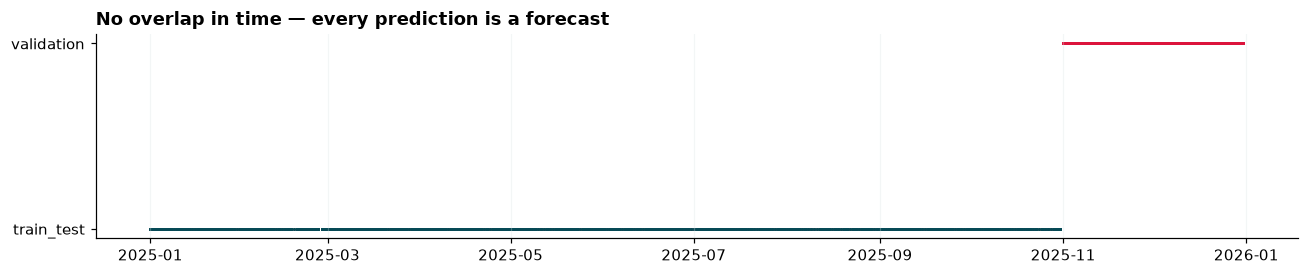

In [22]:
plt.figure(figsize=(12, 2.6))
plt.scatter(train["date"], np.zeros(len(train)), s=1, alpha=0.02, color=ACCENT, label="train")
plt.scatter(val["date"], np.ones(len(val)), s=1, alpha=0.02, color="crimson", label="validation")
plt.yticks([0, 1], ["train_test", "validation"])
plt.title("No overlap in time — every prediction is a forecast",
          loc="left", fontweight="bold")
plt.grid(axis="y", alpha=0)
save("01_time_coverage")
plt.show()

#### Check to see if the validation load looks same as the training load

In [23]:
compare = pd.DataFrame({
    "train": train[["distance", "weight"]].describe().loc[["mean", "50%", "min", "max"]].stack(),
    "validation": val[["distance", "weight"]].describe().loc[["mean", "50%", "min", "max"]].stack(),
}).round(1)
print(compare)

print("\nEquipment mix:")
print(pd.DataFrame({
    "train": train["equipment"].value_counts(normalize=True),
    "validation": val["equipment"].value_counts(normalize=True),
}).round(3))

                 train  validation
mean distance   1135.9      1141.8
     weight    31028.8     30506.6
50%  distance    953.3       953.6
     weight    31436.5     31193.0
min  distance     70.0        70.0
     weight   -47500.0    -47500.0
max  distance   3439.8      3325.7
     weight    47500.0     47500.0

Equipment mix:
           train  validation
equipment                   
Dry Van    0.567       0.565
Reefer     0.251       0.254
Flatbed    0.182       0.181


#### Unseen cities and lanes

In [24]:
train_cities = set(train["pickup"]) | set(train["delivery"])
val_cities = set(val["pickup"]) | set(val["delivery"])
unseen = sorted(val_cities - train_cities)

print(f"Cities in training   : {len(train_cities)}")
print(f"Cities in validation : {len(val_cities)}")
print(f"Never seen in training: {len(unseen)}")
print(unseen)

affected = val["pickup"].isin(unseen) | val["delivery"].isin(unseen)
print(f"\nValidation rows touching an unseen city: {affected.sum():,} ({affected.mean()*100:.1f}%)")

train_lanes = set(zip(train["pickup"], train["delivery"]))
val_lanes = list(zip(val["pickup"], val["delivery"]))
unseen_lane = pd.Series([lane not in train_lanes for lane in val_lanes])
print(f"Validation rows on an unseen lane      : {unseen_lane.sum():,} "
      f"({unseen_lane.mean()*100:.1f}%)")

print("\nDecember chart cities present in training:",
      set(dec['pickup']) | set(dec['delivery']) <= train_cities)

Cities in training   : 64
Cities in validation : 72
Never seen in training: 8
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']

Validation rows touching an unseen city: 1,447 (12.1%)
Validation rows on an unseen lane      : 1,461 (12.2%)

December chart cities present in training: True
